In [1]:
import os

# List all files and directories in the 'downloaded' directory
for root, dirs, files in os.walk('dataset'):
    for file in files:
        print(os.path.join(root, file))
    for dir_name in dirs:
        print(os.path.join(root, dir_name))

dataset/train.csv
dataset/test.csv
dataset/sample_submission.csv
dataset/train
dataset/test
dataset/train/ID871463897.jpg
dataset/train/ID2086966681.jpg
dataset/train/ID1159071020.jpg
dataset/train/ID1457700382.jpg
dataset/train/ID1062837331.jpg
dataset/train/ID875119737.jpg
dataset/train/ID1354190372.jpg
dataset/train/ID1113121340.jpg
dataset/train/ID803479541.jpg
dataset/train/ID1291116815.jpg
dataset/train/ID1693880739.jpg
dataset/train/ID753699705.jpg
dataset/train/ID779628955.jpg
dataset/train/ID50027657.jpg
dataset/train/ID475010202.jpg
dataset/train/ID1182523622.jpg
dataset/train/ID1888700589.jpg
dataset/train/ID407646960.jpg
dataset/train/ID2096636211.jpg
dataset/train/ID545360459.jpg
dataset/train/ID751517087.jpg
dataset/train/ID1579942839.jpg
dataset/train/ID1140993511.jpg
dataset/train/ID1623964968.jpg
dataset/train/ID1634731537.jpg
dataset/train/ID332742639.jpg
dataset/train/ID1477176296.jpg
dataset/train/ID1458758610.jpg
dataset/train/ID1139918758.jpg
dataset/train/ID62696

# Task
Prepare training and test image data generators using `train.csv`, `test.csv`, and the image files in the `downloaded/train` and `downloaded/test` directories to facilitate image classification.

## Load Data

### Subtask:
Load `train.csv` and `test.csv` into pandas DataFrames to access image paths and target labels.


**Reasoning**:
Load the `train.csv` and `test.csv` files into pandas DataFrames as requested in the instructions.



In [2]:
import pandas as pd

train_df = pd.read_csv('dataset/train.csv')
test_df = pd.read_csv('dataset/test.csv')

print("Train DataFrame head:")
print(train_df.head())
print("\nTest DataFrame head:")
print(test_df.head())

Train DataFrame head:
                    sample_id              image_path Sampling_Date State  \
0  ID1011485656__Dry_Clover_g  train/ID1011485656.jpg      2015/9/4   Tas   
1    ID1011485656__Dry_Dead_g  train/ID1011485656.jpg      2015/9/4   Tas   
2   ID1011485656__Dry_Green_g  train/ID1011485656.jpg      2015/9/4   Tas   
3   ID1011485656__Dry_Total_g  train/ID1011485656.jpg      2015/9/4   Tas   
4         ID1011485656__GDM_g  train/ID1011485656.jpg      2015/9/4   Tas   

           Species  Pre_GSHH_NDVI  Height_Ave_cm   target_name   target  
0  Ryegrass_Clover           0.62         4.6667  Dry_Clover_g   0.0000  
1  Ryegrass_Clover           0.62         4.6667    Dry_Dead_g  31.9984  
2  Ryegrass_Clover           0.62         4.6667   Dry_Green_g  16.2751  
3  Ryegrass_Clover           0.62         4.6667   Dry_Total_g  48.2735  
4  Ryegrass_Clover           0.62         4.6667         GDM_g  16.2750  

Test DataFrame head:
                    sample_id             image_p

## Prepare Training Image Generator

### Subtask:
Create a TensorFlow Keras ImageDataGenerator for the training images. This will handle image preprocessing, augmentation (if desired), and batching. We'll link image paths from `train.csv` to the actual image files in `downloaded/train` and associate them with their respective 'target' values.


**Reasoning**:
To prepare the training image generator, I will import `ImageDataGenerator`, instantiate it with scaling and augmentation, and then use `flow_from_dataframe` to link image paths to targets from `train_df`.



In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Instantiate ImageDataGenerator with rescaling and augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Create the training generator
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory='dataset',
    x_col='image_path',
    y_col='target',
    target_size=(224, 224),
    batch_size=32,
    class_mode='raw',
    seed=42
)

print("Training image generator created.")

2025-11-13 22:59:22.697896: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763054962.778512   92359 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763054962.802543   92359 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763054962.965601   92359 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763054962.965642   92359 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763054962.965646   92359 computation_placer.cc:177] computation placer alr

Found 1785 validated image filenames.
Training image generator created.


## Prepare Test Image Generator

### Subtask:
Create a TensorFlow Keras `ImageDataGenerator` for the test images. This generator will handle image preprocessing and batching for the test set, linking image paths from `test.csv` to the actual image files in `downloaded/test`.

#### Instructions
1. Instantiate an `ImageDataGenerator` for testing with `rescale=1./255`. Note that augmentation is typically not applied to the test set.
2. Create the test generator using the `flow_from_dataframe` method, passing `test_df`, `directory='downloaded'`, `x_col='image_path'`, `target_size=(224, 224)` (or another suitable size), `batch_size=32`, and `class_mode=None` (since test data does not have 'target' labels for prediction).
3. Store the created generator in a variable named `test_generator`.

## Prepare Test Image Generator

### Subtask:
Create a TensorFlow Keras `ImageDataGenerator` for the test images. This generator will handle image preprocessing and batching for the test set, linking image paths from `test.csv` to the actual image files in `downloaded/test`.

#### Instructions
1. Instantiate an `ImageDataGenerator` for testing with `rescale=1./255`. Note that augmentation is typically not applied to the test set.
2. Create the test generator using the `flow_from_dataframe` method, passing `test_df`, `directory='downloaded'`, `x_col='image_path'`, `target_size=(224, 224)` (or another suitable size), `batch_size=32`, and `class_mode=None` (since test data does not have 'target' labels for prediction).
3. Store the created generator in a variable named `test_generator`.

**Reasoning**:
Following the previous markdown instruction, I will now create the test image generator using `ImageDataGenerator` with rescaling, ensuring no augmentation for the test set, and then use `flow_from_dataframe` to link image paths from `test_df` to create the `test_generator`.



In [4]:
test_datagen = ImageDataGenerator(
    rescale=1./255
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory='dataset',
    x_col='image_path',
    y_col=None,
    target_size=(224, 224),
    batch_size=32,
    class_mode=None,
    shuffle=False, # Important for consistent predictions later
    seed=42
)

print("Test image generator created.")

Found 5 validated image filenames.
Test image generator created.


## Final Task

### Subtask:
Confirm the successful creation and setup of the image generators.


## Summary:

### Data Analysis Key Findings
*   Both `train.csv` and `test.csv` files were successfully loaded into pandas DataFrames, `train_df` and `test_df` respectively. `train_df` contains `sample_id`, `image_path`, `Sampling_Date`, `State`, `Species`, `Pre_GSHH_NDVI`, `Height_Ave_cm`, `target_name`, and `target` columns. `test_df` contains `sample_id`, `image_path`, and `target_name` columns.
*   A training image generator (`train_generator`) was successfully created using `ImageDataGenerator`. It was configured with image rescaling (1/255) and various augmentation techniques (rotation, width/height shift, shear, zoom, horizontal flip) and found 1785 images from `train_df`.
*   A test image generator (`test_generator`) was successfully created, configured only with image rescaling (1/255), without augmentation, and found 5 images from `test_df`. The `shuffle` parameter was set to `False` for the test generator, which is crucial for consistent prediction ordering.

### Insights or Next Steps
*   The prepared `train_generator` and `test_generator` are now ready to be used as input for training and evaluating an image classification model, respectively.
*   The distinct configurations of the training and test generators (augmentation for training, no augmentation and `shuffle=False` for testing) are appropriate for machine learning best practices, ensuring robust model training and consistent evaluation.


## Define the CNN Model

### Subtask:
Create a convolutional neural network (CNN) model using `tf.keras.Sequential`.

#### Instructions
1. Import necessary components from `tensorflow.keras.models` and `tensorflow.keras.layers`.
2. Initialize a `Sequential` model.
3. Add `Conv2D` layers with `relu` activation and `MaxPooling2D` layers.
4. Add `Dropout` layers for regularization.
5. `Flatten` the output before adding `Dense` layers.
6. The final `Dense` layer should have 1 unit and a linear activation (or no activation) for regression.

In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dense(1, activation='linear') # Output layer for regression (single continuous value)
])

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,202,241 (42.73 MB)

 Trainable params: 11,202,241 (42.73 MB)

 Non-trainable params: 0 (0.00 B)

## Train the CNN Model

### Subtask:
Train the previously defined CNN model using the `train_generator`.

In [14]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [21]:
# Train the model
history = model.fit(
    train_generator,
    epochs=30,
    # verbose=1
)

Epoch 1/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 52s 897ms/step - loss: 690.6580 - mae: 19.2729
Epoch 2/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 50s 888ms/step - loss: 712.6345 - mae: 19.4267
Epoch 3/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 49s 881ms/step - loss: 663.9178 - mae: 18.8429
Epoch 4/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 50s 898ms/step - loss: 687.0845 - mae: 19.1817
Epoch 5/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 50s 891ms/step - loss: 670.2100 - mae: 18.7957
Epoch 6/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 50s 891ms/step - loss: 647.1268 - mae: 18.7387
Epoch 7/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 50s 899ms/step - loss: 664.5753 - mae: 18.8878
Epoch 8/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 50s 893ms/step - loss: 637.5280 - mae: 18.6579
Epoch 9/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 50s 899ms/step - loss: 635.5724 - mae: 18.6006
Epoch 10/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 50s 884ms/step - loss: 644.8406 - mae: 18.6542
Epoch 11/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 50s 892ms/step - loss: 642.7717 - mae: 18.9395
Epoch 12/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 50s 898ms/step - loss: 6

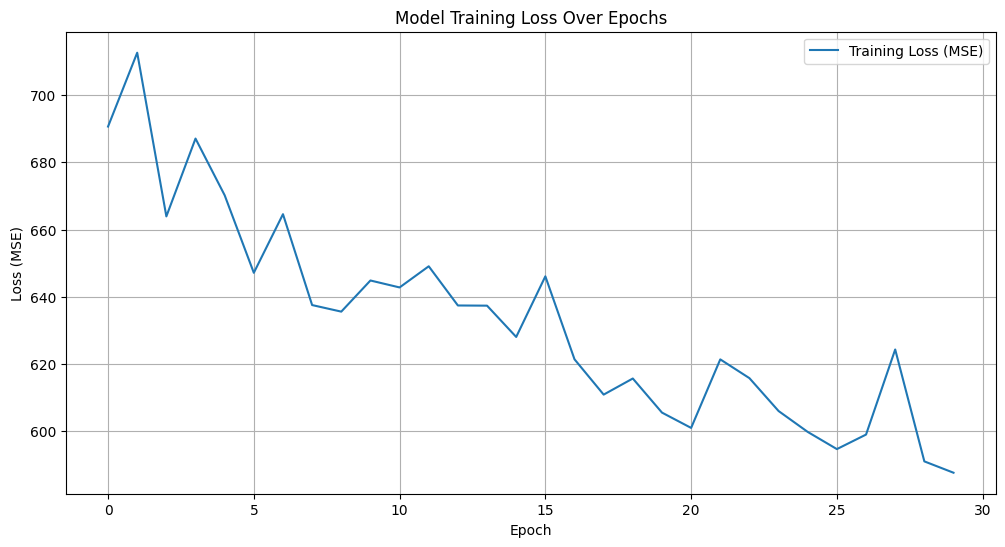

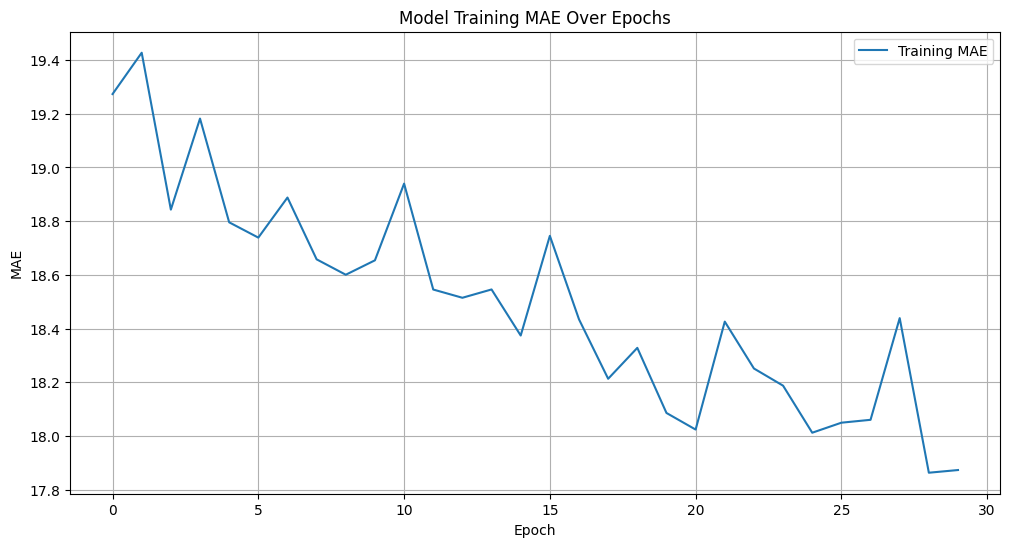

In [22]:
import matplotlib.pyplot as plt

# Plot training loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.title('Model Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# Plot training MAE
plt.figure(figsize=(12, 6))
plt.plot(history.history['mae'], label='Training MAE')
plt.title('Model Training MAE Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Create a new generator for prediction on training data (no augmentation, no labels needed for prediction)
train_predict_datagen = ImageDataGenerator(rescale=1./255)

train_predict_generator = train_predict_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory='dataset',
    x_col='image_path',
    y_col=None, # No labels needed for prediction
    target_size=(224, 224),
    batch_size=32,
    class_mode=None, # Only yield X
    shuffle=False, # Important for consistent order
    seed=42
)

print("Training prediction generator created.")

# Get predictions from the model on the training data
print("Generating predictions for the training dataset...")
train_predictions = model.predict(train_predict_generator)
print("Predictions generated.")

# Extract true target values from the original train_df
true_train_targets = train_df['target'].values.reshape(-1, 1)

# Calculate metrics
mse_train = mean_squared_error(true_train_targets, train_predictions)
mae_train = mean_absolute_error(true_train_targets, train_predictions)

print(f"\nTraining MSE: {mse_train:.4f}")
print(f"Training MAE: {mae_train:.4f}")

Found 1785 validated image filenames.


Training prediction generator created.
Generating predictions for the training dataset...


2025-11-14 00:14:13.838966: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_65', 12 bytes spill stores, 12 bytes spill loads



55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 716ms/step

2025-11-14 00:14:54.774197: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_84', 12 bytes spill stores, 12 bytes spill loads



56/56 ━━━━━━━━━━━━━━━━━━━━ 46s 742ms/step
Predictions generated.

Training MSE: 649.8015
Training MAE: 17.6166


In [26]:
from sklearn.metrics import r2_score
import numpy as np

# Calculate RMSE (Root Mean Squared Error)
rmse_train = np.sqrt(mse_train)

# Calculate R-squared
r2_train = r2_score(true_train_targets, train_predictions)

print(f"Training RMSE: {rmse_train:.4f}")
print(f"Training R-squared: {r2_train:.4f}")

Training RMSE: 25.4912
Training R-squared: 0.0250
